**Mashalov Rasulbek**,
OSTC2U,
Machine Learning,
HomeWork 2,
19th February, 2026.

In [98]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from collections import Counter
import random
import tensorflow as tf
import numpy as np
import cv2
import time

**EXERCISE 1**

In [99]:
#choosing the sample image from dataset
img = X_train[7]

In [100]:
#loading the data
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.cifar10.load_data()

Shape: (32, 32, 3)


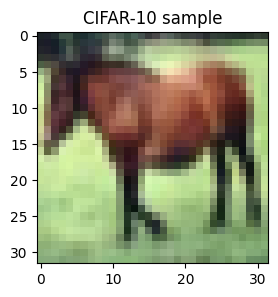

In [101]:
#displaying the sample image and its size
print(f"Shape: {img.shape}")
plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.title("CIFAR-10 sample")
plt.show()

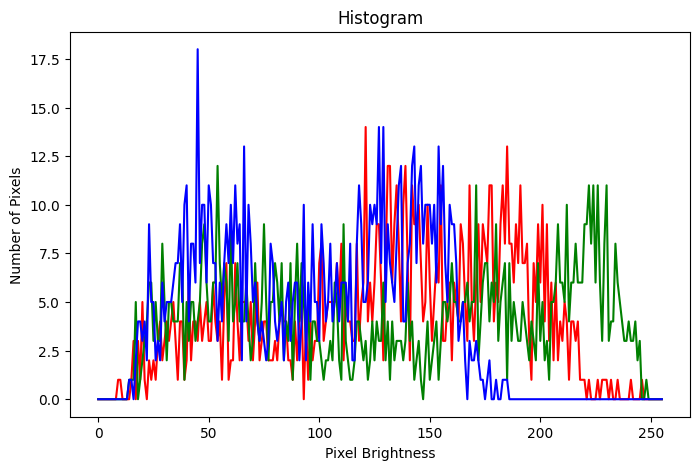

In [102]:
#visualizing
colors = ('r', 'g', 'b')
plt.figure(figsize=(8, 5))
plt.title('Histogram')
plt.xlabel('Pixel Brightness')
plt.ylabel('Number of Pixels')
#looping  thru the channels
for i, color_name in enumerate(colors):
    hist = cv2.calcHist([img], [i], None, [256], [0, 256]) #(0 = Dark, 255 = Bright)

    plt.plot(hist, color=color_name)
plt.show()

**EXERCISE 2/3**

In [103]:
#defining the class/rules for both ex2 and ex3
class MyKNN:
    def __init__(self, k=3, metric='L2'):
        self.k = k
        self.metric = metric

    def fit(self, X_train, Y_train):
        self.X_train = X_train
        self.Y_train = Y_train

    def predict(self, X_test):
        predictions = []

        for x in X_test:
            if self.metric == 'L2':
                #distance of Euclidean
                distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            elif self.metric == 'L1':
                #distance of Manhattan (for ex3)
                distances = np.sum(np.abs(self.X_train - x), axis=1)
            elif self.metric == 'Chebyshev':
                #distance of Chebyshev (for ex3)
                distances = np.max(np.abs(self.X_train - x), axis=1)

            #finding the place of the 'k' closest images and getting the lables
            k_closest_indices = np.argsort(distances)[:self.k]
            k_closest_labels = [self.Y_train[i] for i in k_closest_indices]

            most_common = Counter(k_closest_labels).most_common(1)[0][0]
            predictions.append(most_common)

        return np.array(predictions)

    def score(self, X_test, Y_test):
        predictions = self.predict(X_test)

        correct = np.sum(predictions == Y_test)
        return correct / len(Y_test)

In [104]:
#data preparation, only using first 500 images
test_images = X_test[:500]
test_labels = Y_test[:500]

print(f"Testing on {len(test_images)} images.")

Testing on 500 images.


In [105]:
#reshaping 4d arrays into 2d flat arrays
X_train_flat = X_train.reshape(X_train.shape[0], -1)
test_images_flat = test_images.reshape(test_images.shape[0], -1)

Y_train_flat = Y_train.flatten()
test_labels_flat = test_labels.flatten()

print("[INFO] Testing class MyKNN, default(Euclidean) distance...")
start_time = time.time()

#creating the model
my_model = MyKNN(k=5, metric='L2')

#fitting the model
my_model.fit(X_train_flat, Y_train_flat)

#scoring the model
accuracy = my_model.score(test_images_flat, test_labels_flat)

print(f"[INFO] Accuracy: {accuracy * 100:.2f}%")
print(f"[INFO] Time spent: {time.time() - start_time:.2f} seconds")

[INFO] Testing class MyKNN, default(Euclidean) distance...
[INFO] Accuracy: 24.80%
[INFO] Time spent: 113.31 seconds


**EXERCISE 2/3**

In [106]:
#testing Manhattan
model_l1 = MyKNN(k=5, metric='L1')
model_l1.fit(X_train_flat, Y_train_flat)
acc_l1 = model_l1.score(test_images_flat, test_labels_flat)

#testing Chebyshev
model_cheb = MyKNN(k=5, metric='Chebyshev')
model_cheb.fit(X_train_flat, Y_train_flat)
acc_cheb = model_cheb.score(test_images_flat, test_labels_flat)

print("--- Comparison (k=5) ---")
print(f"L2 (Euclidean) Accuracy: {accuracy * 100:.2f}%")
print(f"L1 (Manhattan) Accuracy: {acc_l1 * 100:.2f}%")
print(f"Chebyshev Accuracy:      {acc_cheb * 100:.2f}%")

--- Comparison (k=5) ---
L2 (Euclidean) Accuracy: 24.80%
L1 (Manhattan) Accuracy: 27.20%
Chebyshev Accuracy:      8.00%
